In [43]:
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
from jax import Array
import numpy

jax.config.update("jax_enable_x64", True)

import zodiax as zdx
import optax

import dLux as dl
import dLux.utils as dlu
from dLux.layers.propagators import Propagator
from dLux.optical_systems import OpticalSystem
from dLux.layers.optical_layers import OpticalLayer

from jax.scipy.special import bessel_jn

from astropy.io import fits

import interpax as ipx

from abcdLux.lct import *
from abcdLux.abcd import *
from abcdLux.fraunhofer import *

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

from lanczos import *

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

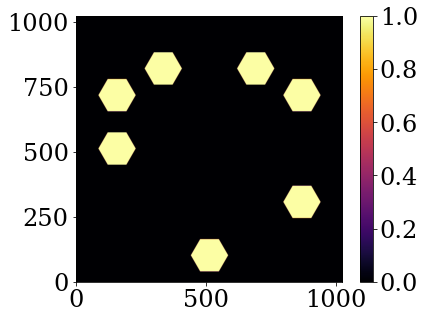

In [44]:
jwst_pupil = np.array(fits.getdata("MASK_NRM.fits",0))
jwst_pupil = jwst_pupil/np.max(jwst_pupil)
plt.imshow(jwst_pupil)
plt.colorbar()

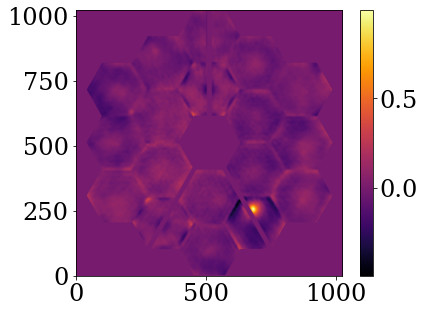

In [45]:
jwst_opd = np.array(fits.getdata("jwst_opd.fits",0))
plt.imshow(jwst_opd)
plt.colorbar()

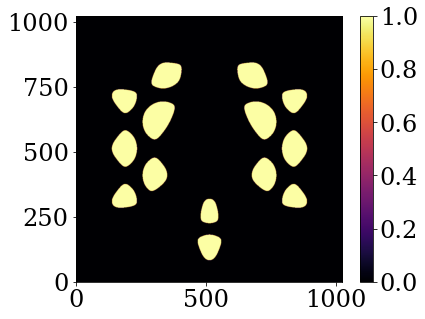

In [46]:
jwst_lyot = np.array(fits.getdata("NIRCam_Lyot_Somb.fits",0))
jwst_lyot = jwst_lyot/np.max(jwst_lyot)
plt.imshow(jwst_lyot)
plt.colorbar()

In [ ]:
wavel = 2.e-6

oversample = 4

npix_out = 80

pupil_ds = 1

npix = 1024

diam = 6.5*1



    

    # ("prop1", dl.FFT(focal_length=131.4, pad=1)),
    # ("occulter", JWSTOcculter(5.253, 1024)),
    # # #("occulter", dl.TransmissiveLayer((transmission), normalise=False)),
    # ("prop1", dl.FFT(focal_length=131.4*1.0, pad=1)),
    # ("lyot", dl.TransmissiveLayer(dlu.pad_to(dlu.downsample(jwst_lyot, pupil_ds), npix), normalise=False)),
    # ("prop1", dl.MFT(256, focal_length=131.4, pixel_scale=18e-6)),

optics = dl.LayeredOpticalSystem(npix, diam,
[

    # ("pupil", dl.TransmissiveLayer(dlu.pad_to(dlu.downsample(jwst_pupil, pupil_ds), npix), normalise=True)),
    # ("opd", dl.AberratedLayer(opd=dlu.pad_to(dlu.downsample(jwst_opd*1e-6, pupil_ds), npix))),

    # ("prop1", dl.FFT(focal_length=131.4, pad=1)),
    # ("occulter", JWSTOcculter(5.253, 1024)),
    # ("prop1", dl.FFT(focal_length=131.4*1.0, pad=1)),




    ("pupil", dl.TransmissiveLayer(dlu.pad_to(dlu.downsample(jwst_pupil, pupil_ds), npix), normalise=True)),
    #("static_opd", dl.AberratedLayer(opd=dlu.pad_to(dlu.downsample(jwst_opd*1e-6, pupil_ds), npix))),
    ("pupil_opd", dl.AberratedLayer(opd=np.zeros((npix, npix)))),


    ("prop1", dl.MFT(npix_out*oversample, focal_length=131.4/2, pixel_scale=18e-6/oversample)),

]
)

# optics = dl.LayeredOpticalSystem(npix, diam,
# [
#     ("pupil", dl.TransmissiveLayer(dlu.downsample(jwst_pupil, 1024//npix), normalise=True)),
#     ("static_opd", dl.AberratedLayer(opd=dlu.downsample(jwst_opd*1e-6, 1024//npix))),
#     ("pupil_opd", dl.AberratedLayer(opd=np.zeros((npix, npix)))),
#         ("prop1", dl.MFT(256, focal_length=131.4, pixel_scale=10e-6)),
#         ("occulter", JWSTOcculter(5.253, 256)),

# ]
# )

# optics = CoronagraphicOpticalSystem(apertures, dists=dists, fls=fls, diams=diams, npixs=npixs)

In [64]:
# simple downsampling detector
detector = dl.LayeredDetector(
    [dl.Downsample(oversample)]
)


source = dl.PointSource(flux=1e9, wavelengths=np.array([4.8e-6]), position=(dlu.arcsec2rad(0.), dlu.arcsec2rad(0.)))


instrument = dl.Telescope(optics, source, detector)

In [65]:
def model_psf(aberrations):
    telescope = instrument.set("pupil_opd.opd", aberrations[:(npix*npix)].reshape((npix, npix)))
    return telescope.model()

In [66]:
injected_dist = np.zeros((npix,npix)).flatten()
img = model_psf(injected_dist)
err = np.sqrt(img + 0**2)
data = jr.normal(jr.key(0),img.shape)*err + img

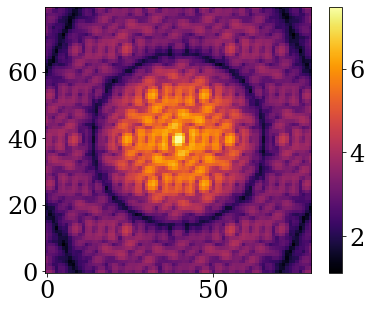

In [70]:
plt.imshow(img**0.125)
plt.colorbar()

In [52]:
# does (up to a sign) what it says on the tin
def likelihood(spectrum, data, err, sum=True):
    psf = model_psf(spectrum)
    if sum:
        return -np.sum(jsp.stats.norm.logpdf(psf, data, err))
    return jsp.stats.norm.logpdf(psf, data, err).flatten()

In [53]:
def hvp(loss, params, v):
  """Computes the hessian vector product Hv.

  This implementation uses forward-over-reverse mode for computing the hvp.

  Args:
    loss: function computing the loss with signature
      loss(params, batch).
    params: pytree for the parameters of the model.
    batch:  A batch of data. Any format is fine as long as it is a valid input
      to loss(params, batch).
    v: pytree of the same structure as params.

  Returns:
    hvp: array of shape [num_params] equal to Hv where H is the hessian.
  """

  loss_fn = lambda x: loss(x)
  return jvp(grad(loss_fn), [params], [v])[1]


In [54]:
tridiag, vecs = lanczos_alg(lambda x: hvp(lambda dist: likelihood(dist, data, err, sum=True), injected_dist, x), npix**2, 200, jax.random.key(0))

In [55]:
vals, vects = np.linalg.eig(tridiag)

In [56]:
vecs.shape

(200, 1048576)

In [57]:
v1 = np.real(np.dot(vects[:,0],vecs))

In [58]:
npix

1024

In [59]:
cmap = matplotlib.colormaps['seismic']
cmap.set_bad('k',1)
support = dlu.pad_to(dlu.downsample(jwst_pupil, pupil_ds), npix)
primary_support = support.at[support < .5].set(np.nan)
support = dlu.pad_to(dlu.downsample(np.flip(jwst_lyot), pupil_ds), npix)
lyot_support = support.at[support < .5].set(np.nan)

([], [])

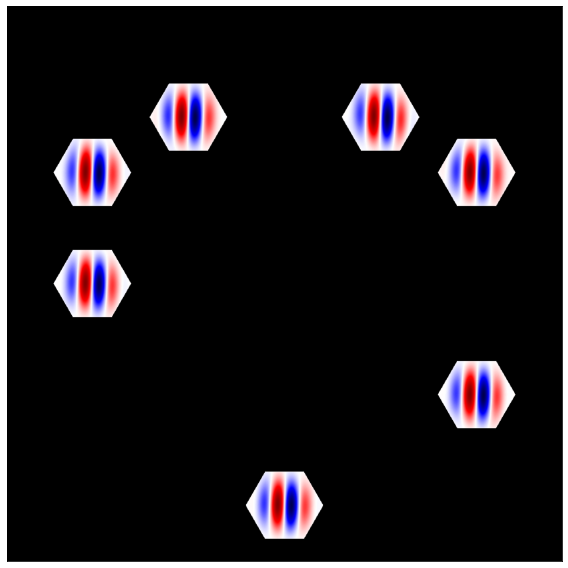

In [60]:
img = v1[:npix*npix].reshape((npix,npix))
vm = np.max(np.abs(img))
plt.figure(figsize=(10,10))
plt.imshow(img*primary_support, vmin=-vm, vmax=vm, cmap=cmap)
plt.xticks([])
plt.yticks([])

In [61]:
vm

Array(0.00981941, dtype=float64)

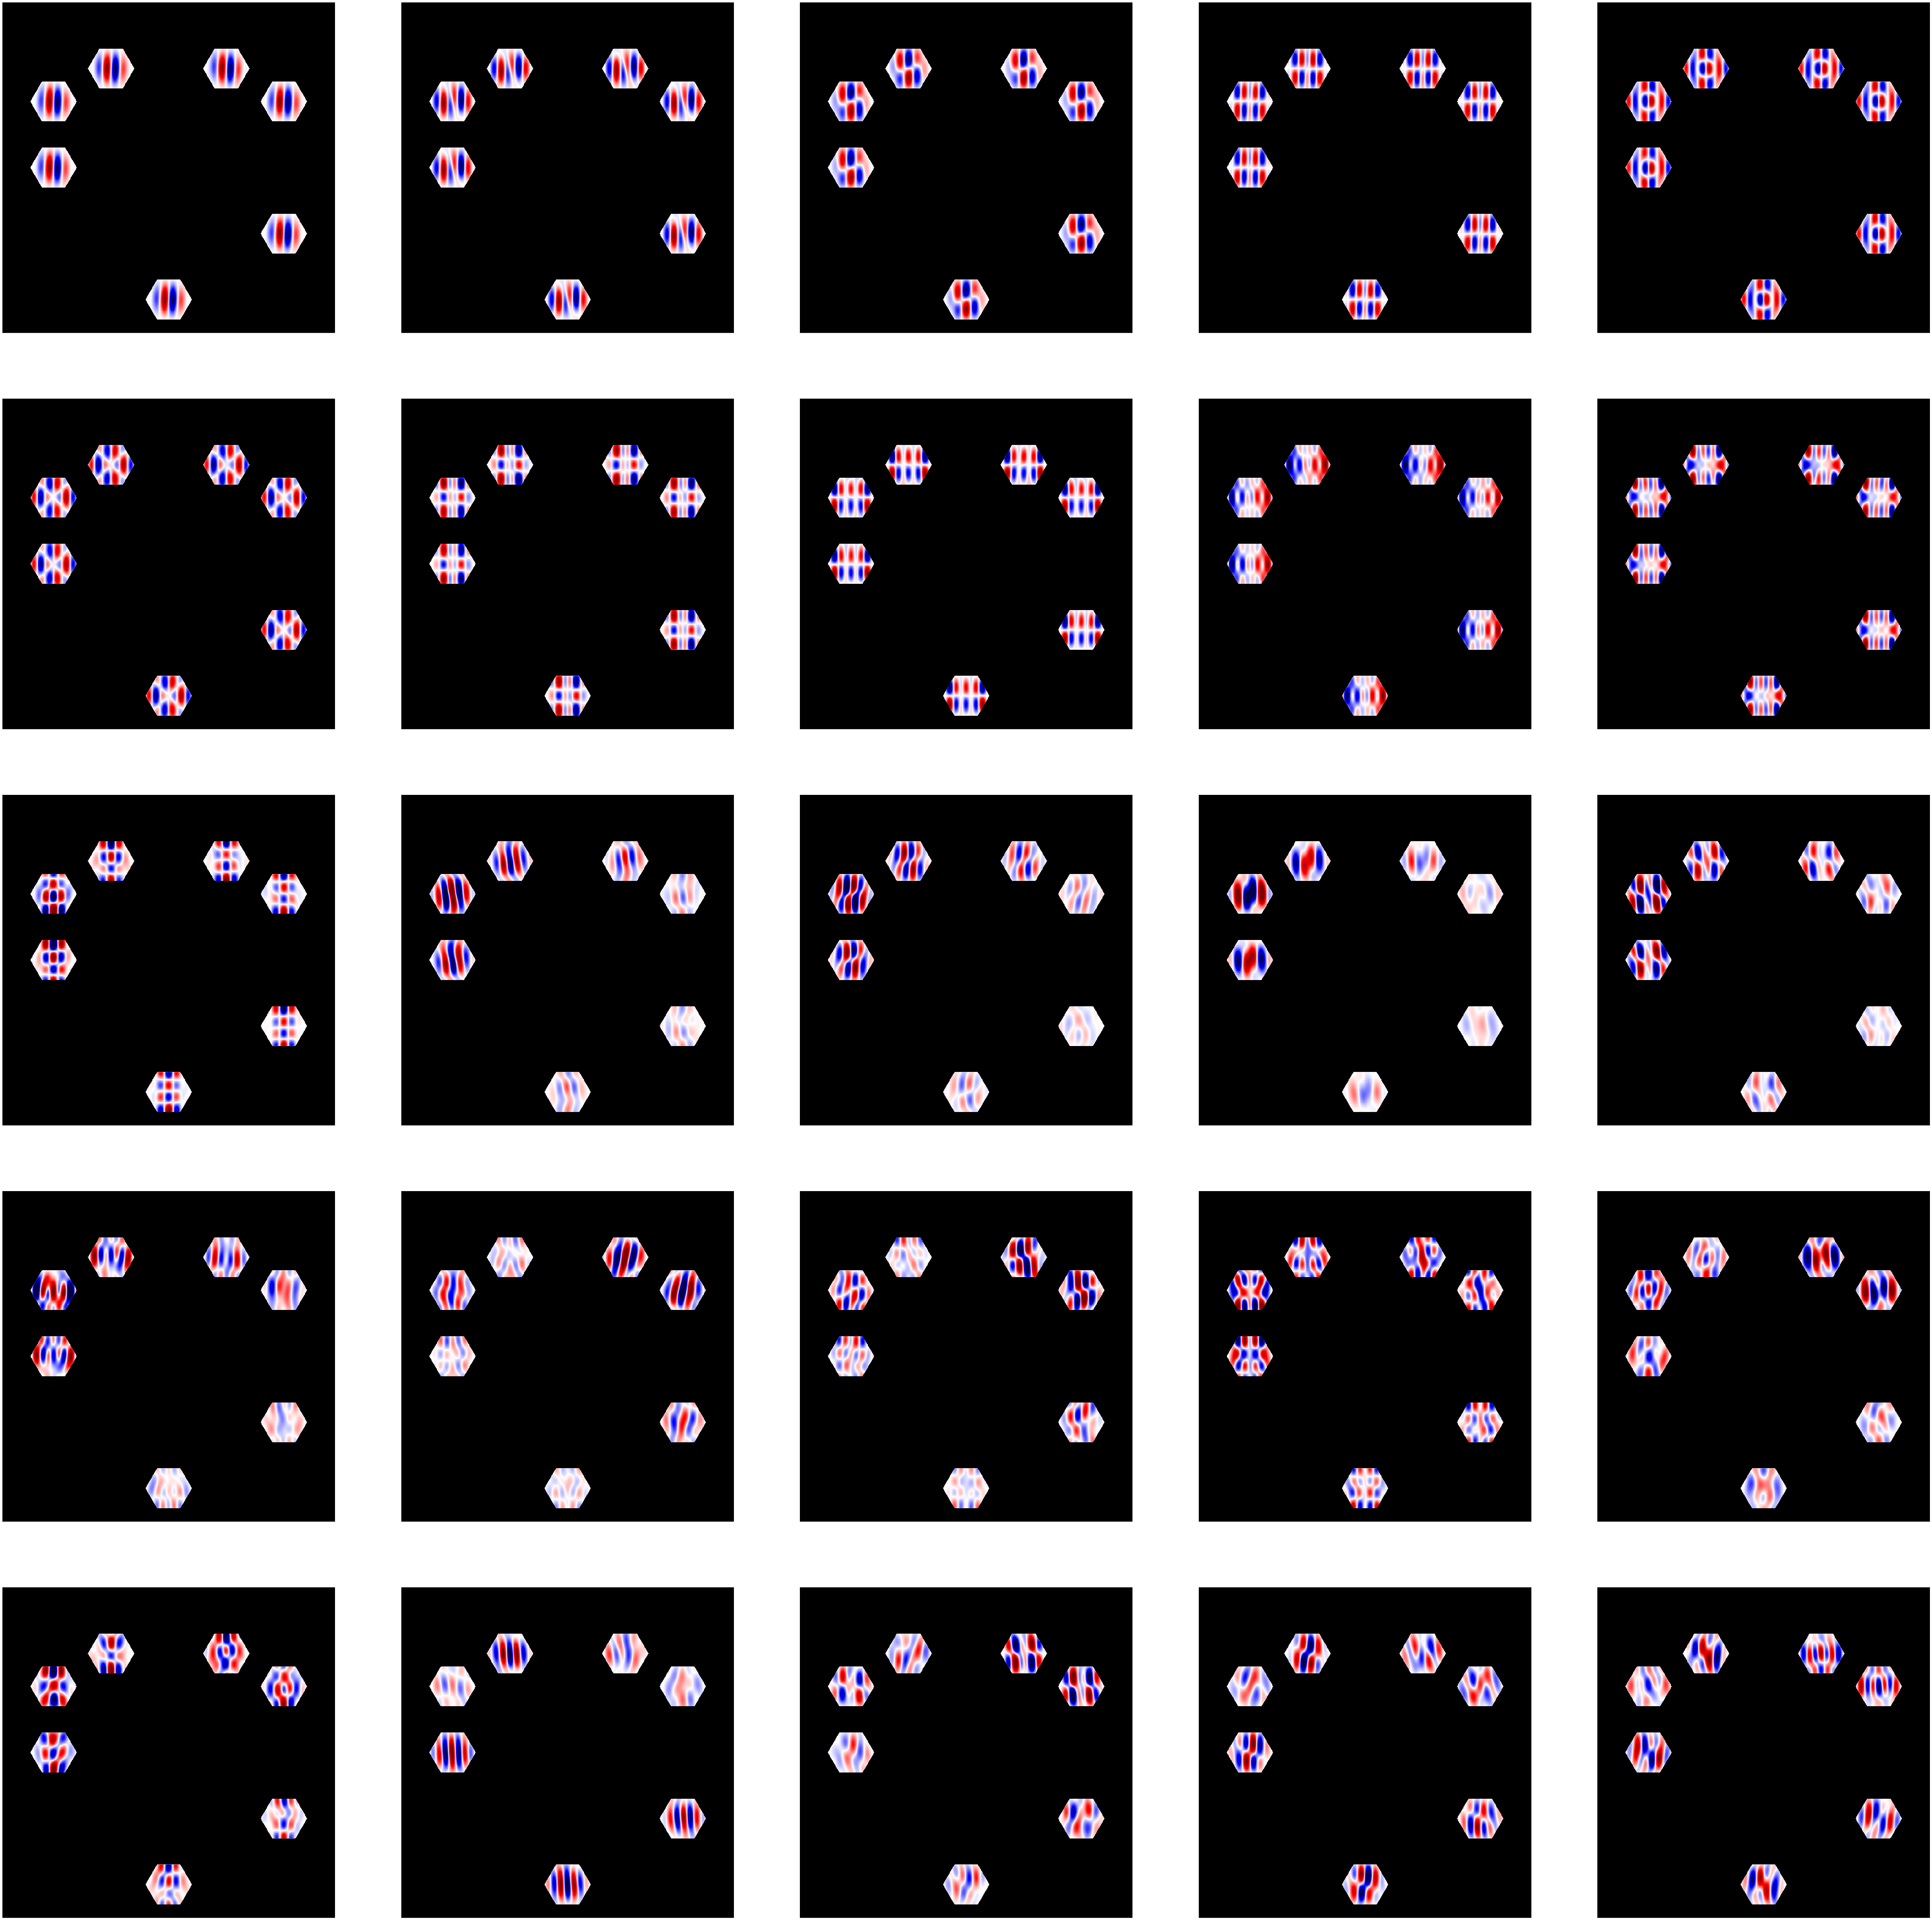

In [62]:
Nx = 5
vm1 = 0.01

fig, axs = plt.subplots(Nx, Nx, figsize=(100,100))
for i in range(Nx):
    for j in range(Nx):
        axs[i,j].imshow(np.real(np.dot(vects[:,i*5+j],vecs))[:npix*npix].reshape((npix,npix))*primary_support, cmap=cmap, interpolation='none', aspect='auto', vmin=-vm1, vmax=vm1)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])


In [63]:
stop

NameError: name 'stop' is not defined

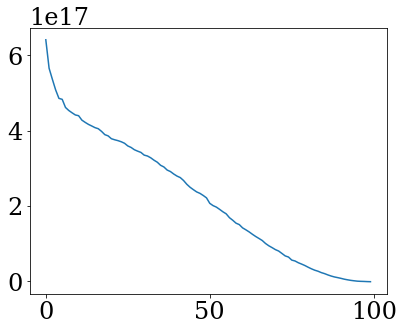

In [ ]:
plt.plot(np.real(vals).sort()[::-1])

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
@jax.jit
def get_hessian(dist):
    return zdx.batching.hessian(lambda dist: likelihood(dist, data, err), dist, nbatches=500)[0]

@jax.jit
def get_jac(dist):
    return zdx.batching.jacobian(lambda dist: likelihood(dist, data, err, sum=False), dist, nbatches=1)[0]

In [ ]:
jac = get_jac(injected_dist)

JitTracer(float64[])


In [ ]:
u, s, vh = np.linalg.svd(jac, compute_uv=True, hermitian=False)

In [ ]:
plt.semilogy(s[:])

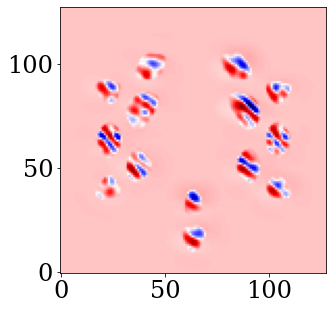

In [ ]:
plt.imshow(vh[5, :128*128].reshape((128,128)), cmap="seismic")

In [ ]:
cmap = matplotlib.colormaps['seismic']
cmap.set_bad('k',1)
support = dlu.pad_to(dlu.downsample(jwst_pupil, pupil_ds), npix)
primary_support = support.at[support < .5].set(np.nan)
support = dlu.pad_to(dlu.downsample(np.flip(jwst_lyot), pupil_ds), npix)
lyot_support = support.at[support < .5].set(np.nan)

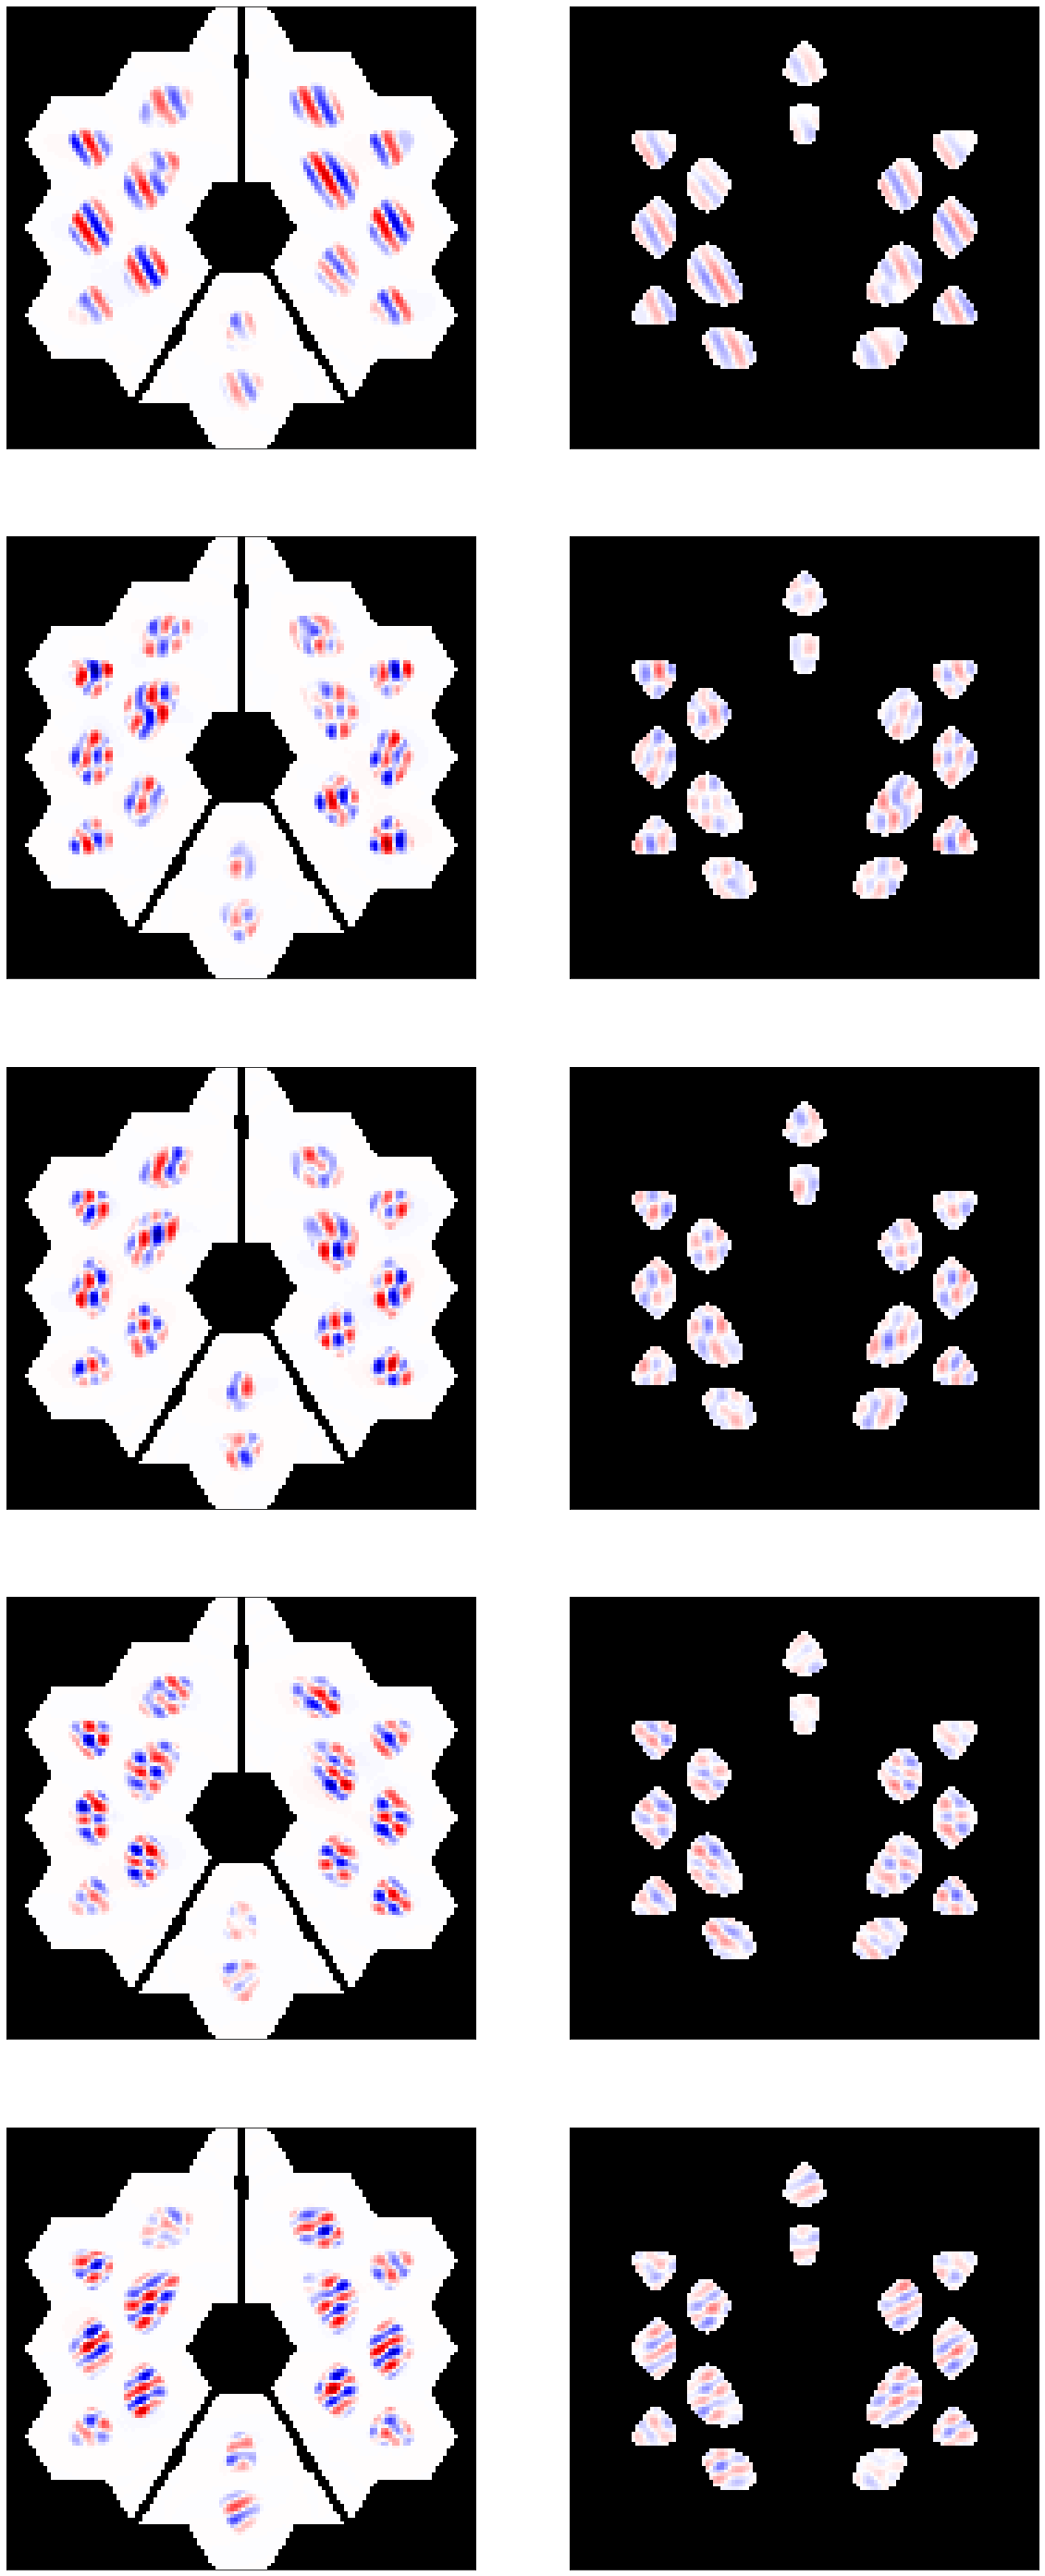

In [ ]:
Nx = 5
fig, axs = plt.subplots(Nx, 2, figsize=(20,50))

vm1 = 0.1
vm2 = 0.1#2e-3

for i in range(Nx):
    vct = vh[i,:(npix*npix)].reshape((npix,npix))
    axs[i,0].imshow(vct*primary_support, cmap=cmap, interpolation='none', aspect='auto', vmin=-vm1, vmax=vm1)
    axs[i,0].set_xticks([])
    axs[i,0].set_yticks([])
    
    vct = vh[i, (npix*npix):].reshape((npix,npix))
    axs[i,1].imshow(vct*lyot_support, cmap=cmap, interpolation='none', aspect='auto', vmin=-vm2, vmax=vm2)
    axs[i,1].set_xticks([])
    axs[i,1].set_yticks([])

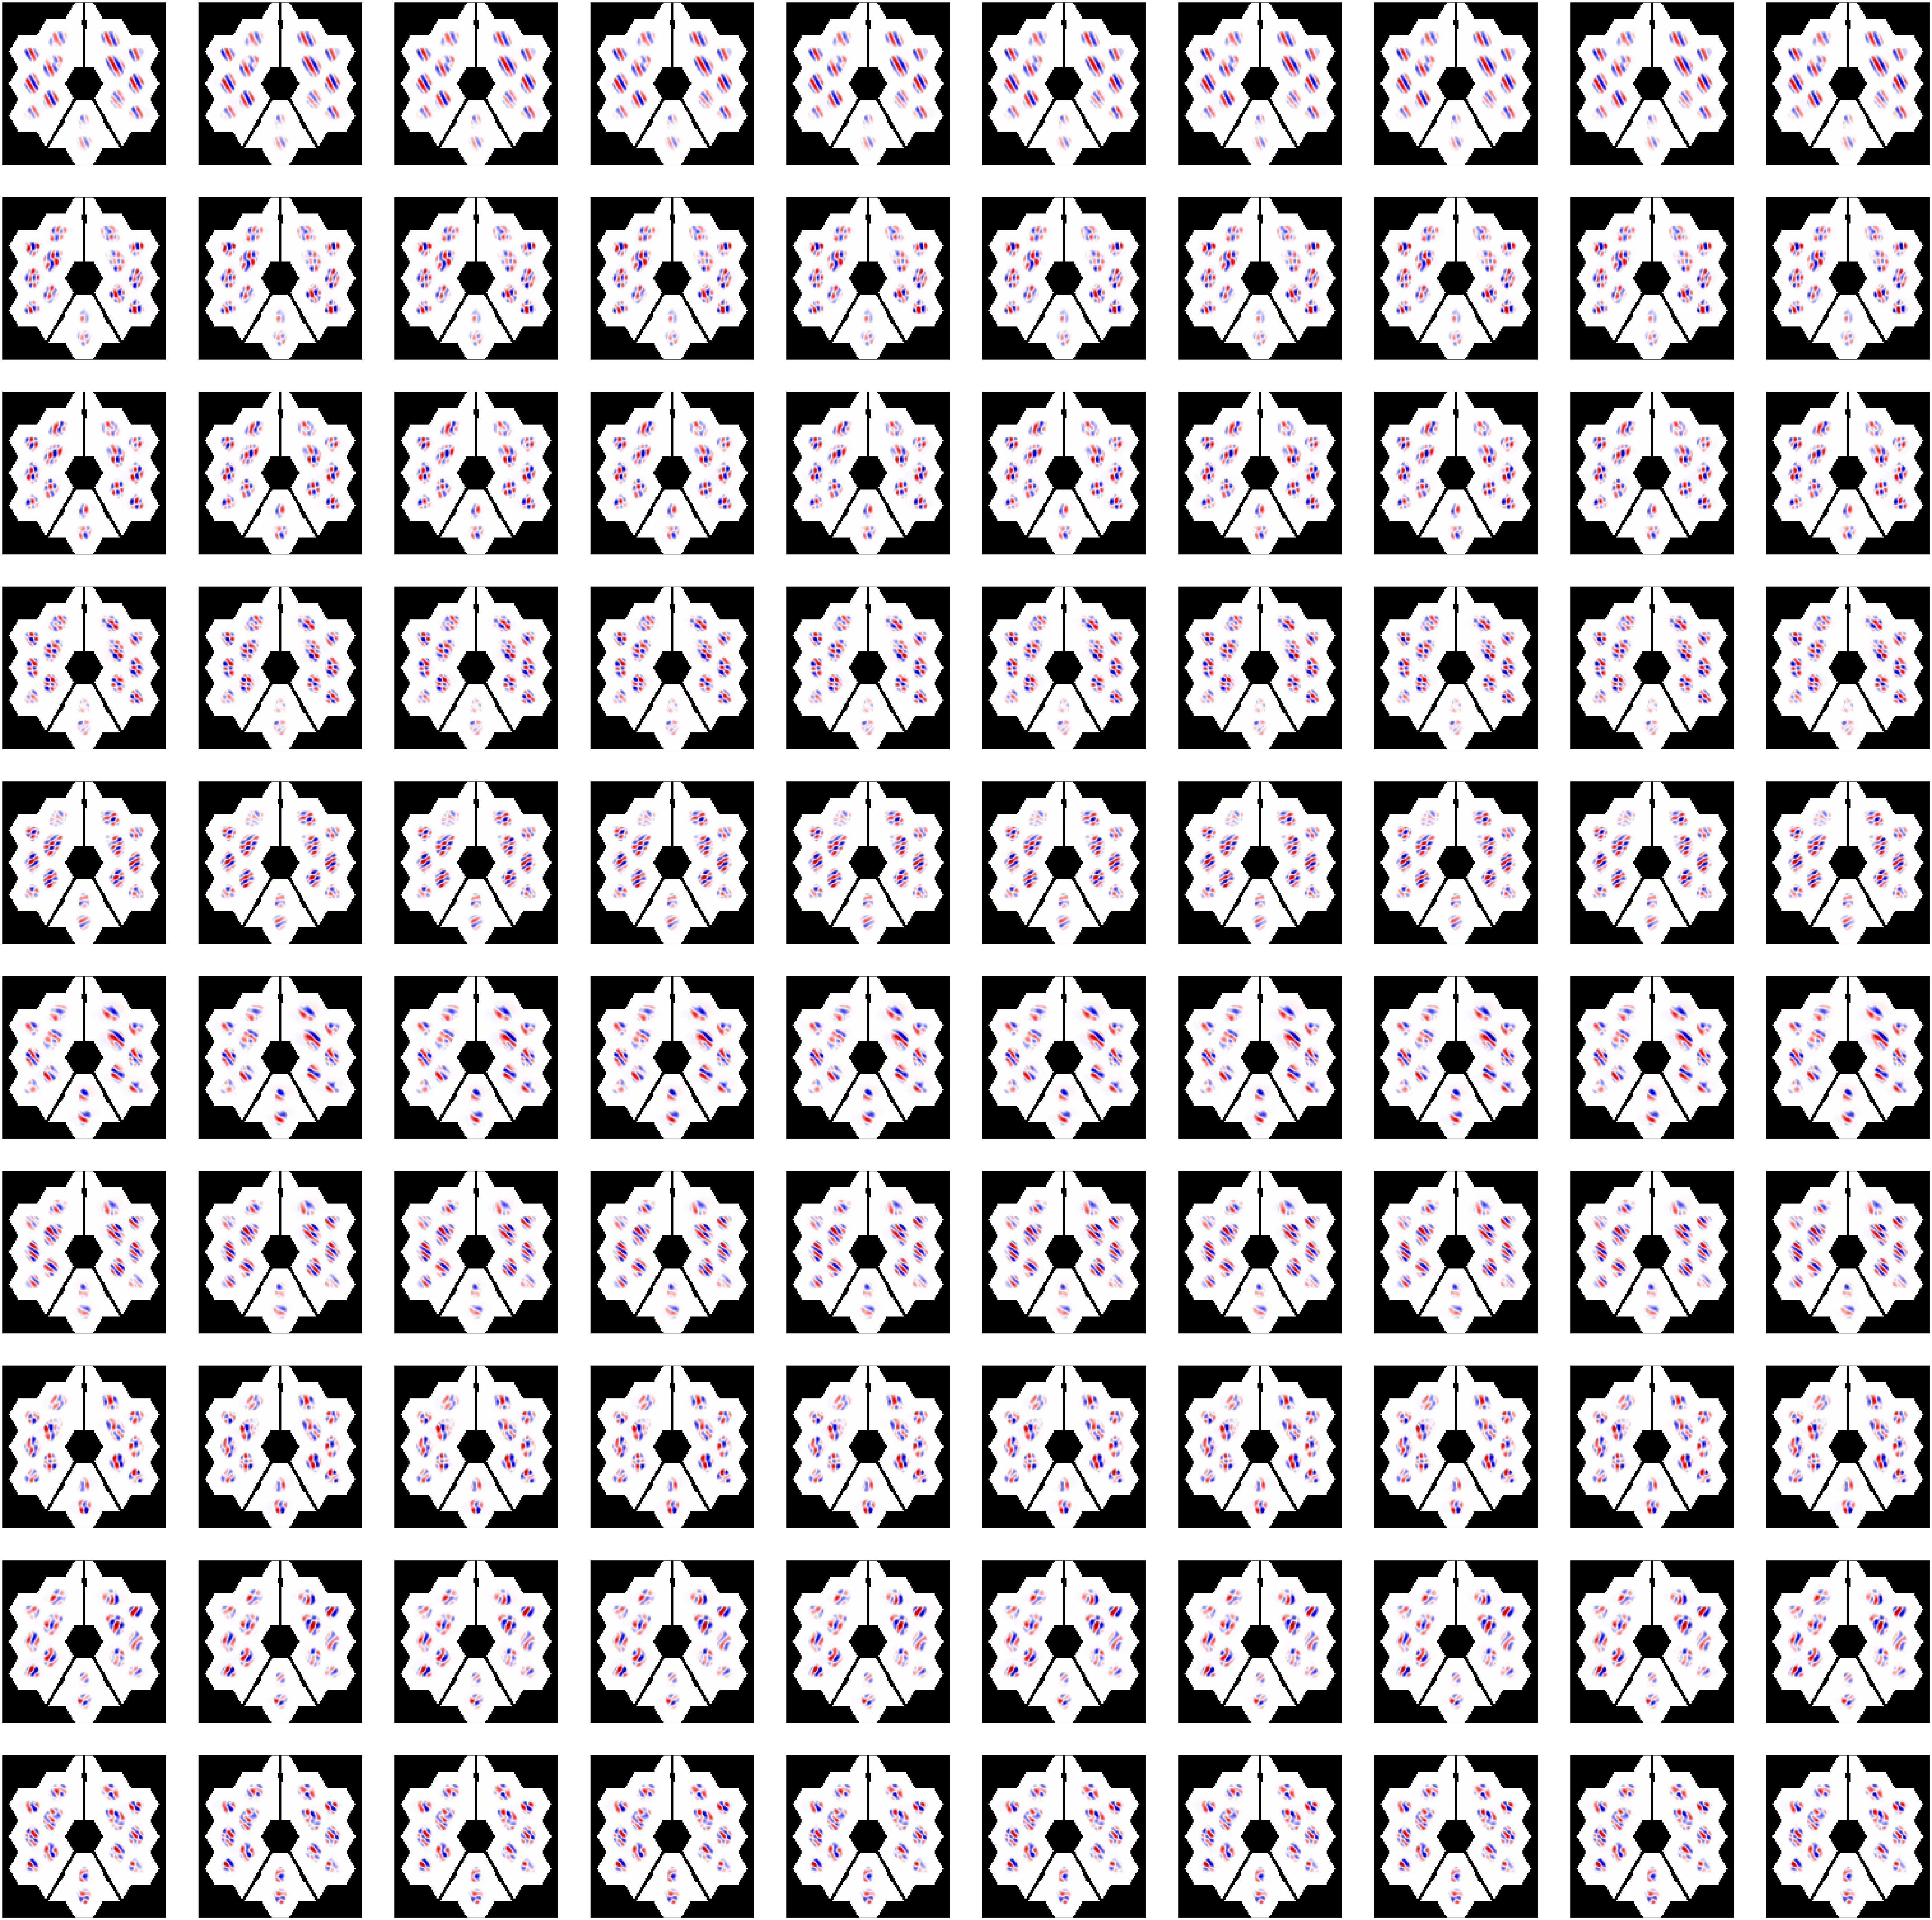

In [ ]:
Nx = 10
vm1 = 0.1

fig, axs = plt.subplots(Nx, Nx, figsize=(100,100))
for i in range(Nx):
    for j in range(Nx):
        axs[i,j].imshow(vh[i,:(npix*npix)].reshape((npix,npix))*primary_support, cmap=cmap, interpolation='none', aspect='auto', vmin=-vm1, vmax=vm1)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])


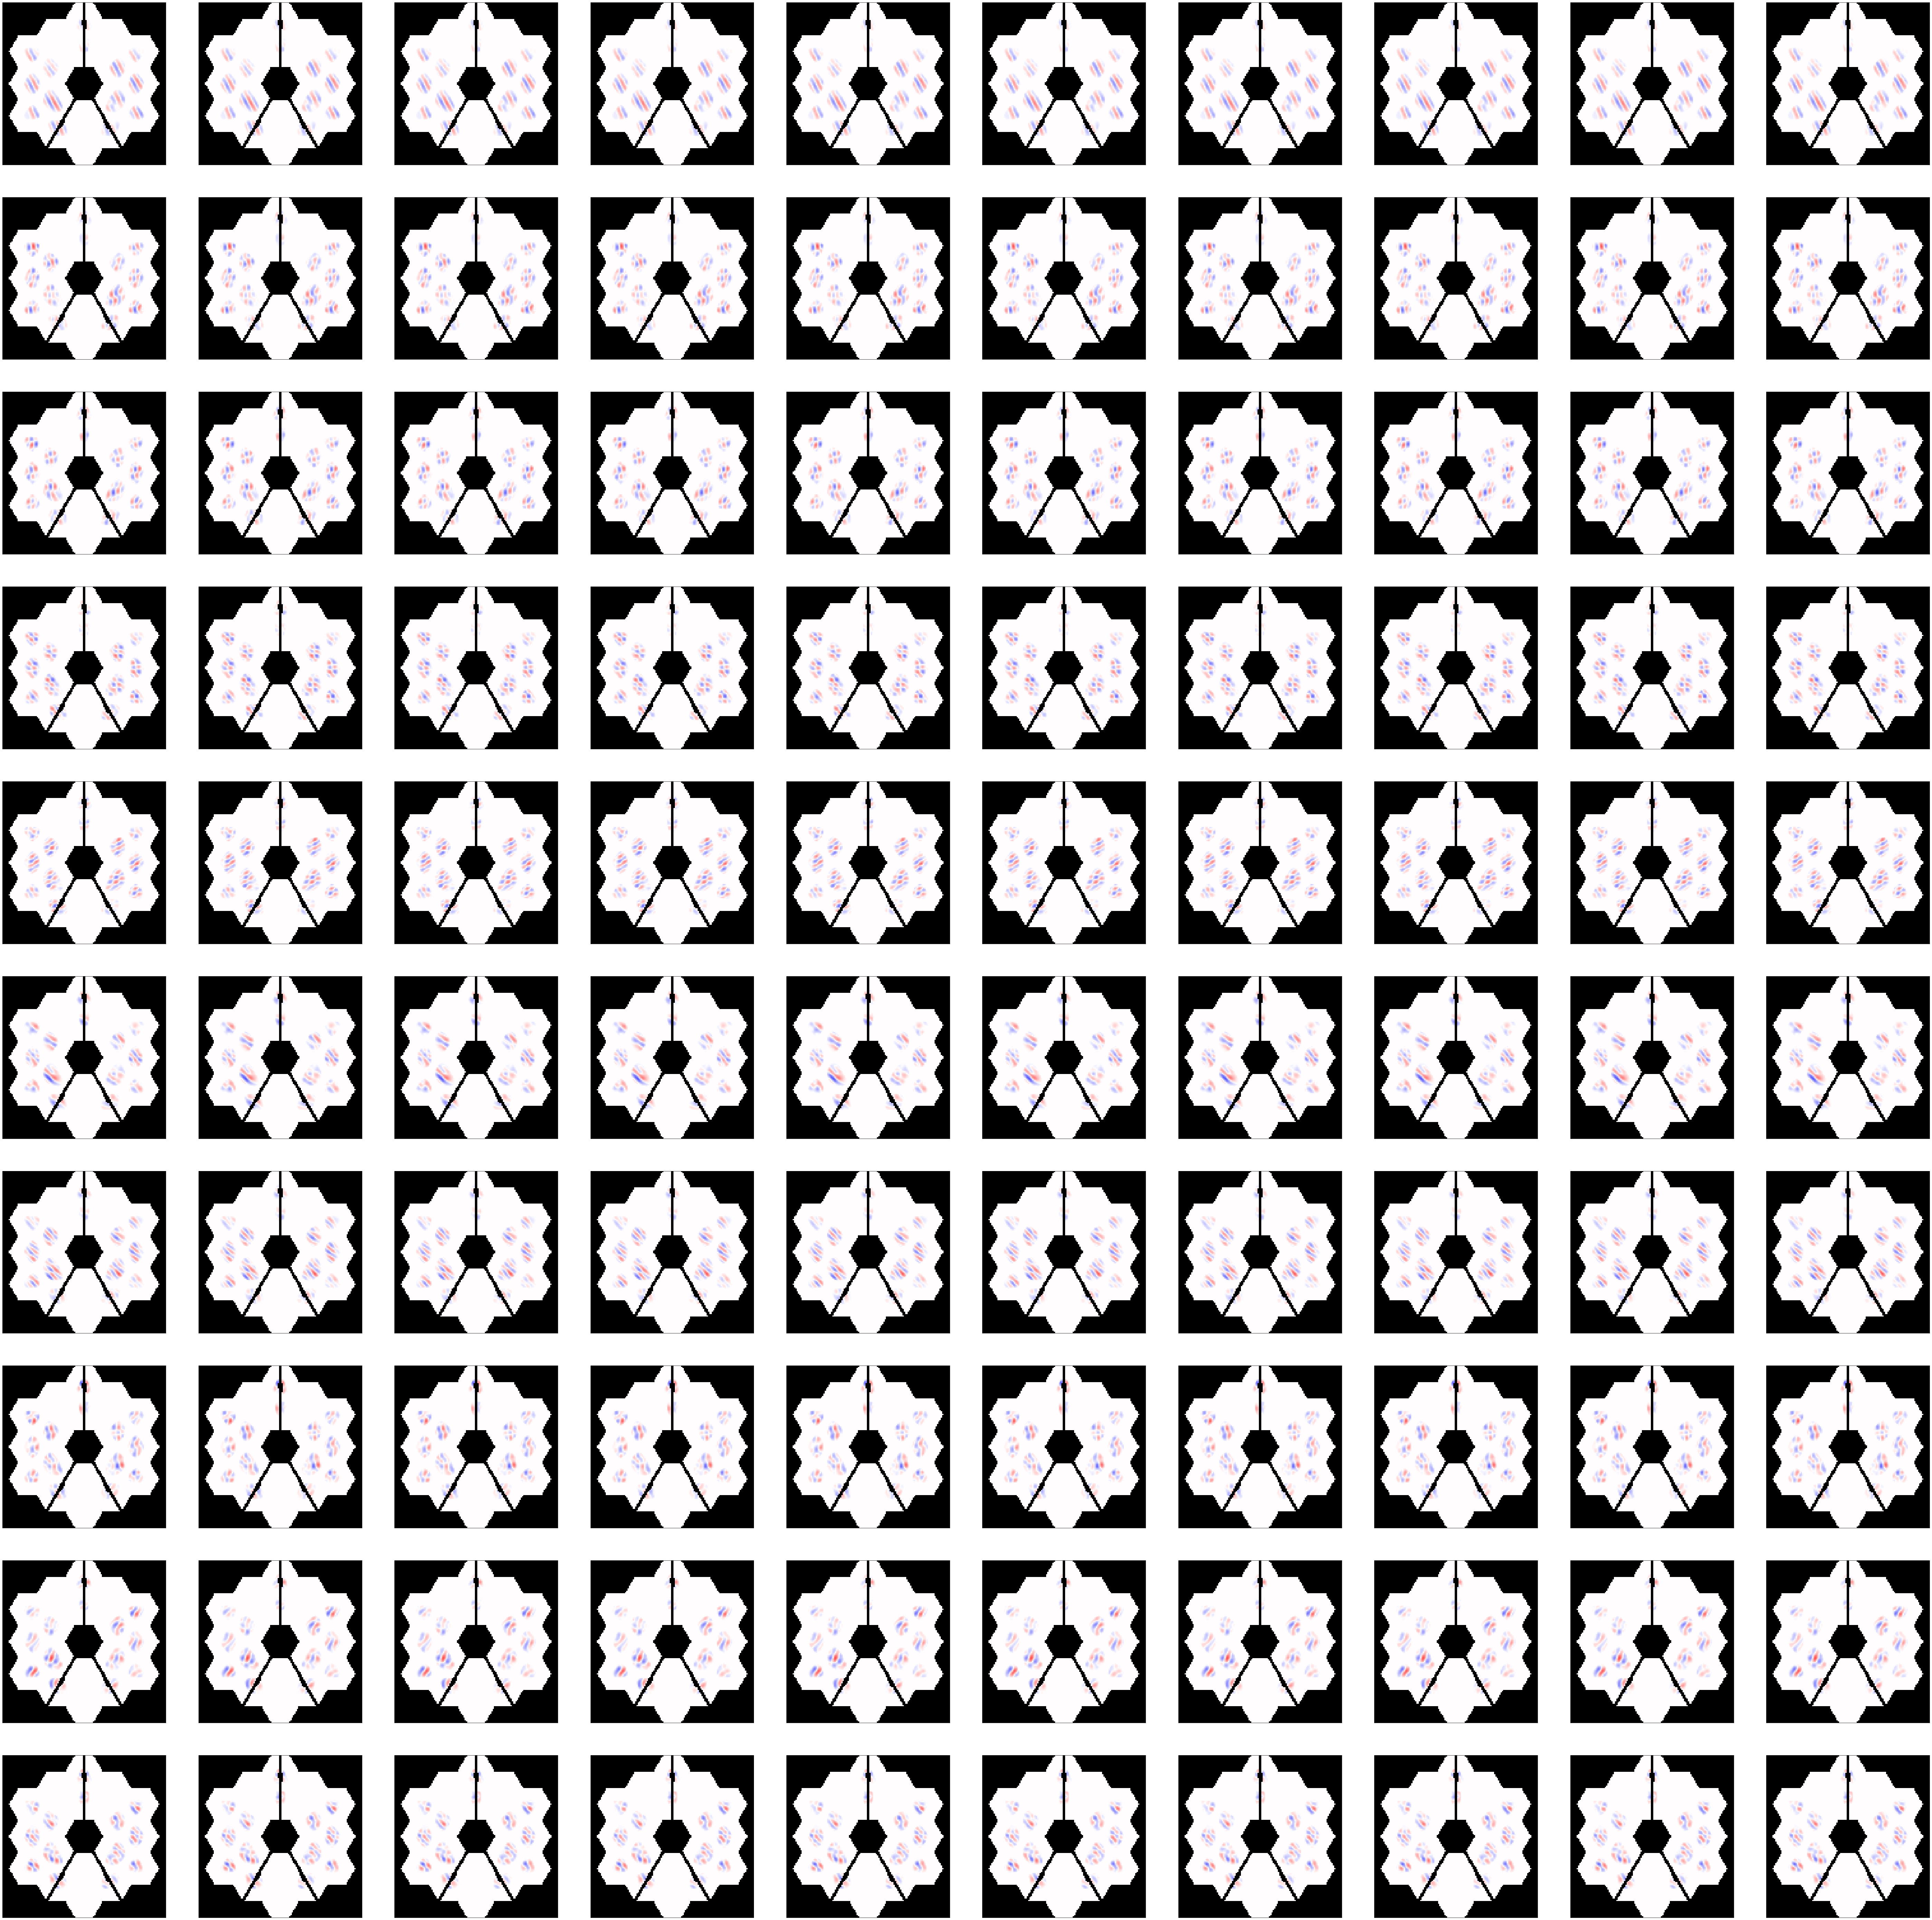

In [ ]:
Nx = 10
fig, axs = plt.subplots(Nx, Nx, figsize=(100,100))
for i in range(Nx):
    for j in range(Nx):
        axs[i,j].imshow(vh[i,(npix*npix):].reshape((npix,npix))*primary_support, cmap=cmap, interpolation='none', aspect='auto', vmin=-vm2, vmax=vm2)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])


In [ ]:
from abcdLux import unpack_coord_spec, pad_to, crop_to, unpack_size

def _shear_fourier(
    u: Array,
    shear: float,
    axis: str,
) -> Array:
    """
    Apply a dimensionless shear using the Fourier shift theorem.
    Parameters
    ----------
    u : Array
        2D field of shape (Ny, Nx).
    shear : float
        Dimensionless shear coefficient, with coordinates measured in pixels.
    axis : str
        "x" : g(x, y) = f(x - shear*y, y)
        "y" : g(x, y) = f(x, y - shear*x)
    Returns
    -------
    Array
        Sheared field, same shape as u.
    """
    Ny, Nx = u.shape
    x, y = unpack_coord_spec(((Nx, Ny), (1.0, 1.0)))

    if axis == "x":
        kx = np.fft.fftfreq(Nx, d=1.0)          # cycles per pixel
        F = np.fft.fft(u, axis=-1)
        phase = np.exp(-2j * np.pi * shear * y[:, None] * kx[None, :])
        return np.fft.ifft(F * phase, axis=-1)

    elif axis == "y":
        ky = np.fft.fftfreq(Ny, d=1.0)          # cycles per pixel
        F = np.fft.fft(u, axis=0)
        phase = np.exp(-2j * np.pi * shear * x[None, :] * ky[:, None])
        return np.fft.ifft(F * phase, axis=0)

    else:
        raise ValueError("axis must be 'x' or 'y'")

def _rotate_fourier(
    u: Array,
    theta: float,
) -> Array:
    """
    Rotate a 2D field by angle theta using the exact three-shear decomposition.
    """
    a = -np.tan(theta / 2.0)
    b = np.sin(theta)

    u = _shear_fourier(u, a, axis="x")
    u = _shear_fourier(u, b, axis="y")
    u = _shear_fourier(u, a, axis="x")

    return u

def fourier_interp(
    u: Array,
    interp_fac: int | tuple[int, int],
) -> Array:
    """
    Fourier interpolation by zero-padding the Fourier plane.
    Assumes unit pixel spacing on input, so output spacing becomes
    smaller by the padding factor.
    """
    Ny_in, Nx_in = u.shape
    padfac_y, padfac_x = unpack_size(interp_fac)

    Ny_out = padfac_y * Ny_in
    Nx_out = padfac_x * Nx_in

    u_fft = np.fft.fftshift(np.fft.fft2(u))
    u_fft_pad = pad_to(u_fft, (Ny_out, Nx_out))

    u_interp = (Ny_out / Ny_in) * (Nx_out / Nx_in) * np.fft.ifft2(
        np.fft.ifftshift(u_fft_pad)
    )
    return u_interp

def fourier_rotate(
    u: Array,
    theta: float,
    pad_fac: int | tuple[int, int] = 2,
    interp_fac: int | tuple[int, int] = 2,
    real: bool = True,
) -> Array:
    """
    Rotate a 2D field by angle theta using the exact three-shear decomposition.
    Applying the method from Larkin et al. (1997), we pad in both the spatial
    and Fourier domains before performing the three-shear rotation.
    """

    Ny_in, Nx_in = u.shape
    npad = (Nx_in*pad_fac, Ny_in*pad_fac)
    u_pad = pad_to(u, npad)
    u_interp = fourier_interp(u_pad, interp_fac)
    u_rot = _rotate_fourier(u_interp, theta)
    u_crop = crop_to(u_rot[::interp_fac, ::interp_fac], (Nx_in, Ny_in))
    if real:
        return np.real(u_crop)
    else:
        return u_crop

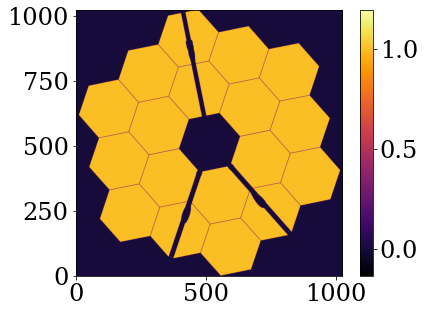

In [ ]:
plt.imshow(fourier_rotate(jwst_pupil, 0.2))
plt.colorbar()

(array([1.20000e+01, 2.80000e+01, 4.40000e+01, 2.01000e+02, 3.34000e+02,
        4.28000e+02, 5.79000e+02, 1.18600e+03, 3.53400e+03, 2.28730e+04,
        3.82577e+05, 6.11700e+03, 1.78200e+03, 9.27000e+02, 5.77000e+02,
        3.10000e+02, 3.03000e+02, 2.93000e+02, 3.38000e+02, 3.36000e+02,
        2.79000e+02, 2.87000e+02, 2.62000e+02, 2.64000e+02, 2.27000e+02,
        2.83000e+02, 2.52000e+02, 2.83000e+02, 2.93000e+02, 2.51000e+02,
        2.42000e+02, 3.01000e+02, 2.86000e+02, 2.40000e+02, 2.75000e+02,
        2.70000e+02, 2.46000e+02, 2.31000e+02, 2.29000e+02, 2.05000e+02,
        2.23000e+02, 2.03000e+02, 2.22000e+02, 2.46000e+02, 2.06000e+02,
        2.17000e+02, 2.03000e+02, 2.05000e+02, 1.87000e+02, 2.09000e+02,
        2.10000e+02, 2.13000e+02, 2.14000e+02, 2.05000e+02, 2.11000e+02,
        2.12000e+02, 2.18000e+02, 2.06000e+02, 1.67000e+02, 2.29000e+02,
        2.23000e+02, 2.17000e+02, 2.11000e+02, 2.29000e+02, 2.21000e+02,
        2.53000e+02, 2.41000e+02, 2.16000e+02, 2.42

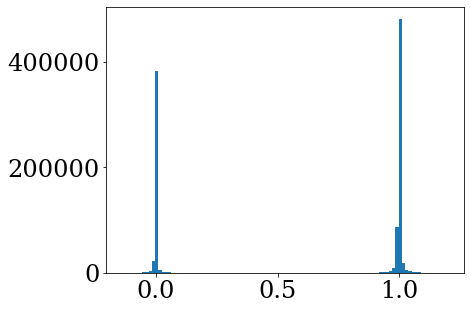

In [ ]:
plt.hist(fourier_rotate(jwst_pupil, 0.2).flatten(), bins=100)